In [1]:
import numpy as np
import pickle as pkl

import concurrent.futures
import pickle as pkl
import time
from one.api import ONE
import pandas as pd
from tqdm import tqdm
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units
from brainbox.singlecell import bin_spikes2D
from iblatlas.regions import BrainRegions
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from ibl_info.utils import check_config, compute_animal_stats, get_trial_masks_detailed
from scipy.ndimage import convolve1d
import traceback
from scipy.stats import zscore

In [2]:
with open("../data/processed/all_eids_dict.pkl", "rb") as f:
    x = pkl.load(f)

In [18]:
x["03063955-2523-47bd-ae57-f7489dd40f15"]

,goCueTrigger_times,intervals_bpod_0,intervals_bpod_1,quiescencePeriod,stimOffTrigger_times,stimOff_times,stimOnTrigger_times,goCue_times,response_times,choice,...,probabilityLeft,feedback_times,feedbackType,rewardVolume,firstMovement_times,intervals_0,intervals_1,prior,prediction_error_left,prediction_error_right
0,157.659559,0.000000,8.592003,0.610104,158.917268,158.991933,157.585258,157.660199,157.917161,1.0,...,0.5,157.917273,1.0,1.5,157.794558,150.899909,159.491975,0.500000,0.018441,0.981559
1,165.251616,8.998300,18.158503,0.603376,168.494540,168.558476,165.182815,165.252473,167.494432,1.0,...,0.5,167.494549,1.0,1.5,167.375558,159.898275,169.058547,0.580995,0.175857,0.824143
2,170.201757,18.607700,21.158802,0.618698,171.469674,171.558776,170.126556,170.202411,170.469561,1.0,...,0.5,170.469651,1.0,1.5,170.363558,169.507748,172.058884,0.648869,0.018441,0.981559
3,173.084892,21.538900,31.792402,0.559975,182.111046,182.192479,172.999091,173.085723,180.110934,1.0,...,0.5,180.111987,-1.0,0.0,178.523558,172.438988,182.692552,0.705749,0.401886,0.598114
4,185.201272,32.222200,36.100902,0.674887,186.428783,186.501048,185.115371,185.201945,185.428674,1.0,...,0.5,185.428789,1.0,1.5,185.222558,183.122353,187.001090,0.753415,0.030149,0.969851
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
862,4769.488129,4617.935599,4621.236401,0.551339,4771.607069,4771.670952,4769.421639,4769.489003,4769.606942,1.0,...,0.2,4769.607992,-1.0,0.0,4769.470558,4768.870132,4772.170978,0.291126,0.800041,0.199959
863,4773.794961,4622.342599,4627.386301,0.445818,4777.758405,4777.820837,4773.723193,4773.795639,4775.758299,1.0,...,0.2,4775.759276,-1.0,0.0,4775.609558,4773.277191,4778.320909,0.405956,0.830608,0.169392
864,4779.911705,4628.481099,4630.793801,0.427684,4781.157924,4781.228363,4779.843514,4779.912561,4780.157816,1.0,...,0.2,4780.157936,1.0,1.5,4779.767558,4779.415711,4781.728430,0.502185,0.018441,0.981559
865,4783.621032,4631.889899,4638.793301,0.534684,4789.145386,4789.227963,4783.554142,4783.621857,4787.145270,1.0,...,0.2,4787.146138,-1.0,0.0,4784.457558,4782.824536,4789.727992,0.582826,0.515814,0.484186


In [6]:
one = ONE(
    base_url="https://openalyx.internationalbrainlab.org",
    username="intbrainlab",
    password="international",
)

Connected to https://openalyx.internationalbrainlab.org as user "intbrainlab"


In [19]:
eidx = "03063955-2523-47bd-ae57-f7489dd40f15"

In [20]:
trials, mask = load_trials_and_mask(one, eidx, exclude_unbiased=True, exclude_nochoice=True)

(S3) /Users/dkundu/Downloads/ONE/openalyx.internationalbrainlab.org/mrsicflogellab/Subjects/SWC_038/2020-08-01/001/alf/_ibl_trials.intervals_bpod.npy: 100%|██████████| 14.0k/14.0k [00:00<00:00, 32.1kB/s]
(S3) /Users/dkundu/Downloads/ONE/openalyx.internationalbrainlab.org/mrsicflogellab/Subjects/SWC_038/2020-08-01/001/alf/_ibl_trials.quiescencePeriod.npy: 100%|██████████| 7.06k/7.06k [00:00<00:00, 22.3kB/s]


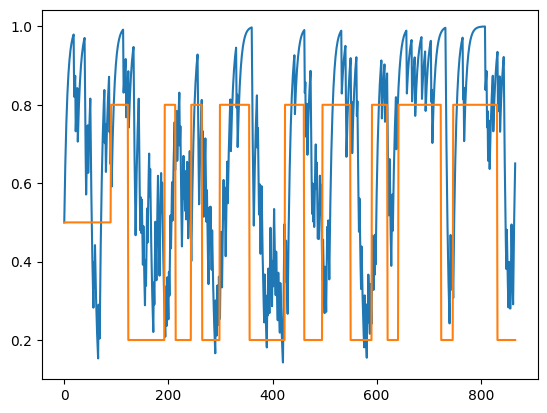

In [21]:
plt.plot(x[eidx]["prior"])
plt.plot(trials["probabilityLeft"])

In [26]:
trials[mask]

,goCueTrigger_times,intervals_bpod_0,intervals_bpod_1,quiescencePeriod,stimOff_times,goCue_times,firstMovement_times,probabilityLeft,feedback_times,contrastLeft,feedbackType,rewardVolume,choice,contrastRight,stimOn_times,response_times,intervals_0,intervals_1
90,619.395683,467.941200,470.425602,0.454986,620.829011,619.396587,619.6418,0.8,619.738987,NaN,1.0,1.5,-1.0,1.0000,619.395588,619.738888,618.844676,621.329112
91,622.336521,470.876200,473.675603,0.465144,624.079019,622.337193,622.6978,0.8,622.994328,0.0625,1.0,1.5,1.0,NaN,622.336393,622.994228,621.779716,624.579147
98,656.218971,502.366500,507.164102,0.518765,657.567803,656.219838,656.3658,0.8,656.485378,1.0000,1.0,1.5,1.0,NaN,656.218838,656.485271,653.270266,658.067875
99,659.678683,507.626800,512.107902,0.479124,662.511642,659.679459,661.2238,0.8,661.435616,0.0625,1.0,1.5,1.0,NaN,659.678492,661.435497,658.530574,663.011712
100,664.069619,512.564900,515.458102,0.518918,665.861907,664.070420,664.3508,0.8,664.785148,1.0000,1.0,1.5,1.0,NaN,664.069453,664.785027,663.468713,666.361945
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
847,4468.742239,4317.276399,4319.900601,0.451959,4470.332855,4468.743148,4468.9748,0.2,4469.249230,NaN,1.0,1.5,-1.0,1.0000,4468.742114,4469.249143,4468.208734,4470.832957
848,4474.075480,4320.978999,4339.065702,0.437794,4489.498172,4474.076414,4474.3228,0.2,4488.419480,NaN,1.0,1.5,-1.0,0.0625,4474.075314,4488.419381,4471.911364,4489.998196
850,4508.615118,4356.518299,4361.008701,0.451175,4511.441277,4508.616060,4510.2748,0.2,4510.366452,NaN,1.0,1.5,-1.0,0.0625,4508.614993,4510.366331,4507.450910,4511.941345
855,4584.864693,4433.379599,4436.948202,0.473273,4587.381349,4584.865634,4586.1388,0.2,4586.302891,NaN,1.0,1.5,-1.0,0.0000,4584.864501,4586.302804,4584.312790,4587.881418


In [31]:
x["03063955-2523-47bd-ae57-f7489dd40f15"][mask]["prior"]

90     0.705510
91     0.591225
98     0.881360
99     0.900579
100    0.916684
         ...   
847    0.542595
848    0.454700
850    0.481308
855    0.334665
858    0.397012
Name: prior, Length: 513, dtype: float32

In [36]:
tx = x[eidx][mask]

In [53]:
# >0.5 is left block
# <=0.5 is right block

In [ ]:
tx_ = tx.copy()
tx_["expect_left"] = tx_["prior"] > 0.5

# 2. Define the actual stimulus
is_L_stim = tx_["contrastLeft"] > 0
is_R_stim = tx_["contrastRight"] > 0

# 3. Congruence is when Expectation matches Reality
tx_["is_congruent"] = (tx_["expect_left"] & is_L_stim) | (~tx_["expect_left"] & is_R_stim)
tx_["is_incongruent"] = (tx_["expect_left"] & is_R_stim) | (~tx_["expect_left"] & is_L_stim)

In [58]:
tx_

,goCueTrigger_times,intervals_bpod_0,intervals_bpod_1,quiescencePeriod,stimOffTrigger_times,stimOff_times,stimOnTrigger_times,goCue_times,response_times,choice,...,rewardVolume,firstMovement_times,intervals_0,intervals_1,prior,prediction_error_left,prediction_error_right,expect_left,is_congruent,is_incongruent
90,619.395683,467.941200,470.425602,0.454986,620.739002,620.829011,619.299782,619.396587,619.738888,-1.0,...,1.5,619.641558,618.844676,621.329112,0.705510,0.897036,0.102964,True,False,True
91,622.336521,470.876200,473.675603,0.465144,623.994338,624.079019,622.245020,622.337193,622.994228,1.0,...,1.5,622.697558,621.779716,624.579147,0.591225,0.274416,0.725584,True,True,False
98,656.218971,502.366500,507.164102,0.518765,657.485372,657.567803,656.145870,656.219838,656.485271,1.0,...,1.5,656.365558,653.270266,658.067875,0.881360,0.018441,0.981559,True,True,False
99,659.678683,507.626800,512.107902,0.479124,662.435605,662.511642,659.601882,659.679459,661.435497,1.0,...,1.5,661.224558,658.530574,663.011712,0.900579,0.058126,0.941874,True,True,False
100,664.069619,512.564900,515.458102,0.518918,665.785137,665.861907,663.987819,664.070420,664.785027,1.0,...,1.5,664.350558,663.468713,666.361945,0.916684,0.018441,0.981559,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
847,4468.742239,4317.276399,4319.900601,0.451959,4470.249251,4470.332855,4468.660838,4468.743148,4469.249143,-1.0,...,1.5,4468.992558,4468.208734,4470.832957,0.542595,0.897072,0.102928,True,False,True
848,4474.075480,4320.978999,4339.065702,0.437794,4489.419488,4489.498172,4474.005579,4474.076414,4488.419381,-1.0,...,1.5,4474.325558,4471.911364,4489.998196,0.454700,0.624842,0.375158,False,True,False
850,4508.615118,4356.518299,4361.008701,0.451175,4511.366439,4511.441277,4508.527618,4508.616060,4510.366331,-1.0,...,1.5,4510.283558,4507.450910,4511.941345,0.481308,0.603070,0.396930,False,True,False
855,4584.864693,4433.379599,4436.948202,0.473273,4587.302911,4587.381349,4584.786193,4584.865634,4586.302804,-1.0,...,1.5,4586.123558,4584.312790,4587.881418,0.334665,0.643418,0.356582,False,False,False


In [59]:
# also get percentage of correct previous trials for each condition

In [60]:
tx_.to_csv("../data/external/actionkernel_prior.csv")

In [63]:
from ibl_info.manifold import get_action_kernel_congruence

In [69]:
real_tx_masks, cond_names = get_action_kernel_congruence(eidx, trial_mask=mask)

In [85]:
def get_preceding_reward_history(trials, masks, n=1):
    """
    Computes the preceding reward history for different trial conditions.
    """

    is_correct = (trials["feedbackType"] == 1).astype(float)
    rolling_correct_sum = is_correct.shift(1).rolling(window=n, min_periods=1).sum()
    rolling_correct_mean = is_correct.shift(1).rolling(window=n, min_periods=1).mean()

    results = {}
    for condition_name, mask in masks.items():

        avg_sum_for_cond = rolling_correct_sum[mask].mean()
        avg_mean_for_cond = rolling_correct_mean[mask].mean()

        results[condition_name] = {
            "avg_number_of_correct_preceding_n": avg_sum_for_cond,
            "avg_proportion_correct_preceding_n": avg_mean_for_cond,
        }

    return results

In [86]:
rx = get_preceding_reward_history(tx_, real_tx_masks)

In [73]:
rx

{'L_Cong_Corr': {'avg_number_of_correct_preceding_n': np.float64(0.8691588785046729),
  'avg_proportion_correct_preceding_n': np.float64(0.8691588785046729)},
 'R_Incong_Corr': {'avg_number_of_correct_preceding_n': np.float64(0.7088607594936709),
  'avg_proportion_correct_preceding_n': np.float64(0.7088607594936709)},
 'R_Cong_Corr': {'avg_number_of_correct_preceding_n': np.float64(0.8513513513513513),
  'avg_proportion_correct_preceding_n': np.float64(0.8513513513513513)},
 'L_Incong_Corr': {'avg_number_of_correct_preceding_n': np.float64(0.7894736842105263),
  'avg_proportion_correct_preceding_n': np.float64(0.7894736842105263)}}

In [74]:
is_correct = (trials["feedbackType"] == 1).astype(float)

In [75]:
is_correct

0      1.0
1      1.0
2      1.0
3      0.0
4      1.0
      ... 
862    0.0
863    0.0
864    1.0
865    0.0
866    1.0
Name: feedbackType, Length: 867, dtype: float64

In [82]:
is_correct.shift(1).rolling(window=4, min_periods=3).mean()

0       NaN
1       NaN
2       NaN
3      1.00
4      0.75
       ... 
862    0.75
863    0.75
864    0.50
865    0.50
866    0.25
Name: feedbackType, Length: 867, dtype: float64